
🎓  WELCOME TO SMART STUDENT PERFORMANCE ANALYZER  🎓

Please provide the following details:

 Enter Student Name: Rutuja Shende
 Study hours per day (1–8): 6
 Sleep hours per day (4–10): 8
 Attendance percentage (0–100): 75
 Stress level (1–10): 5
 Previous semester score (0–10 or %): 8.23
 Internet usage (hours per day): 4

------------------------------------------------------------
📈 STUDENT PERFORMANCE PREDICTION RESULT for Rutuja Shende
------------------------------------------------------------
 Linear Regression Predicted CGPA : 8.66
 ANN Predicted CGPA              : 7.86
 Performance Category             :  Average Performer
 Cluster Group                    : Balanced Learner

 Personalized Recommendation:
 Good effort! Focus on consistency and time management.
------------------------------------------------------------


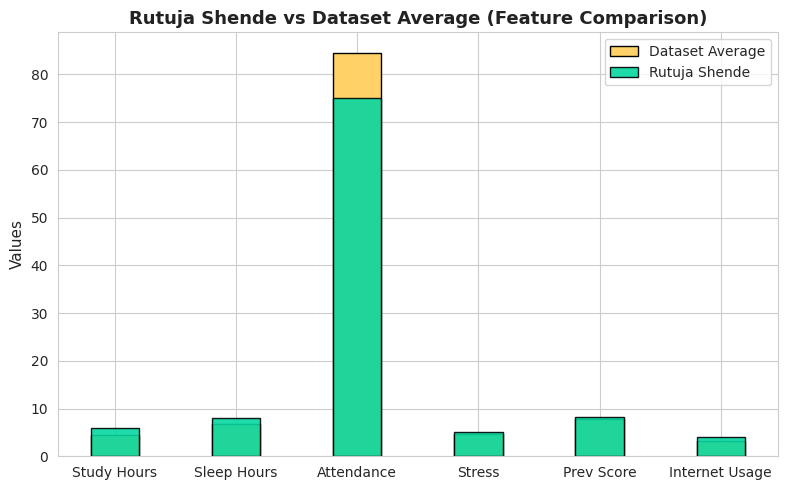


           --- Please Wait, Generating Radar Chart ---




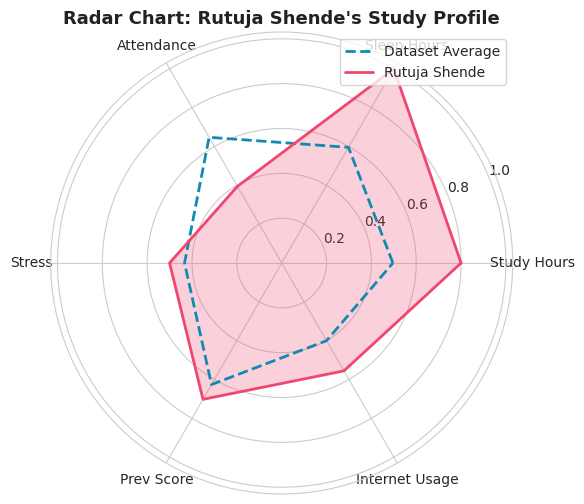


 Would you like to analyze another student? (yes/no): y

🎉 Thank you for using Smart Student Performance Analyzer! Have a great day!



In [ ]:
# ==========================================================
# SMART STUDENT PERFORMANCE ANALYZER
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_style("whitegrid")

# ----------------------------------------------------------
# Dataset
# ----------------------------------------------------------
data = pd.DataFrame({
    "study_hours": [2,3,4,5,6,2,3.5,6.5,4.5,5.5,4,5,3,6.2,7],
    "sleep_hours": [6,7,6.5,8,7,5,6,7.5,6.8,7,7.2,6.5,6,7.8,7.5],
    "attendance": [70,80,90,95,85,60,75,92,88,94,89,84,73,96,98],
    "stress_level": [7,5,4,3,4,8,6,3,5,4,5,4,6,3,2],
    "previous_score": [6,7,8,9,8.5,5,6.8,9.2,8.4,9,7.8,8.3,6.2,9.4,9.6],
    "internet_usage": [5,4,3,2,2.5,6,5,2,3,2,3.5,2.5,5.5,2,1.5],
    "cgpa": [6.2,7.0,7.8,9.0,8.7,5.4,6.8,9.3,8.4,9.1,7.9,8.5,6.4,9.5,9.7]
})

FEATURES = ["study_hours","sleep_hours","attendance","stress_level","previous_score","internet_usage"]
X = data[FEATURES]
y = data["cgpa"]

# ----------------------------------------------------------
# Preprocessing
# ----------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ----------------------------------------------------------
# Models
# ----------------------------------------------------------
regressor = LinearRegression().fit(X_train, y_train)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)

# Simple ANN (from scratch)
np.random.seed(42)
input_size, hidden_size, output_size = 6, 4, 1
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

def relu(x): return np.maximum(0, x)
def relu_derivative(x): return np.where(x > 0, 1, 0)
def ann_predict(X_new):
    X_scaled = scaler.transform(pd.DataFrame(X_new, columns=FEATURES))
    z1 = np.dot(X_scaled, W1) + b1
    a1 = relu(z1)
    z2 = np.dot(a1, W2) + b2
    return np.clip(z2.flatten(), 1, 10)

# ANN Training
lr = 0.01
epochs = 600
X_train_arr, y_train_arr = np.array(X_train), np.array(y_train).reshape(-1, 1)
for _ in range(epochs):
    z1 = np.dot(X_train_arr, W1) + b1
    a1 = relu(z1)
    z2 = np.dot(a1, W2) + b2
    y_hat = z2
    dloss_dy = -2 * (y_train_arr - y_hat)
    dW2 = np.dot(a1.T, dloss_dy) / len(X_train_arr)
    db2 = np.sum(dloss_dy, axis=0, keepdims=True) / len(X_train_arr)
    da1 = np.dot(dloss_dy, W2.T)
    dz1 = da1 * relu_derivative(z1)
    dW1 = np.dot(X_train_arr.T, dz1) / len(X_train_arr)
    db1 = np.sum(dz1, axis=0, keepdims=True) / len(X_train_arr)
    W1 -= lr * dW1; b1 -= lr * db1; W2 -= lr * dW2; b2 -= lr * db2

# ----------------------------------------------------------
# Input Validation
# ----------------------------------------------------------
def validate_inputs(study_hours, sleep_hours, attendance, stress_level, previous_score, internet_usage):
    if previous_score > 10: previous_score /= 10
    if sleep_hours > 12:
        print(" Warning: Sleep hours unusually high → adjusted to 8.")
        sleep_hours = 8
    if study_hours > 10:
        print("  Warning: Study hours unusually high → adjusted to 6.")
        study_hours = 6
    if attendance > 100: attendance = 95
    return study_hours, sleep_hours, attendance, stress_level, previous_score, internet_usage

# ----------------------------------------------------------
# MAIN LOOP (Analyze Multiple Students)
# ----------------------------------------------------------
print("\n" + "="*60)
print("🎓  WELCOME TO SMART STUDENT PERFORMANCE ANALYZER  🎓")
print("="*60)

while True:
    print("\nPlease provide the following details:\n")
    name = input(" Enter Student Name: ").strip().title()
    study_hours = float(input(" Study hours per day (1–8): "))
    sleep_hours = float(input(" Sleep hours per day (4–10): "))
    attendance = float(input(" Attendance percentage (0–100): "))
    stress_level = float(input(" Stress level (1–10): "))
    previous_score = float(input(" Previous semester score (0–10 or %): "))
    internet_usage = float(input(" Internet usage (hours per day): "))

    # Validate Inputs
    study_hours, sleep_hours, attendance, stress_level, previous_score, internet_usage = \
        validate_inputs(study_hours, sleep_hours, attendance, stress_level, previous_score, internet_usage)

    # Predict
    input_data = pd.DataFrame([[study_hours, sleep_hours, attendance, stress_level, previous_score, internet_usage]],
                              columns=FEATURES)
    predicted_lr = np.clip(regressor.predict(scaler.transform(input_data))[0], 1, 10)
    predicted_ann = ann_predict(input_data)[0]
    cluster_group = kmeans.predict(scaler.transform(input_data))[0]

    cluster_map = {0: "Hard Worker", 1: "Balanced Learner", 2: "Needs Focus"}
    cluster_name = cluster_map.get(cluster_group, f"Cluster {cluster_group}")

    if predicted_ann >= 8:
        category = " High Performer"
        advice = "Excellent work! Keep consistent performance and help peers."
    elif predicted_ann >= 6:
        category = " Average Performer"
        advice = "Good effort! Focus on consistency and time management."
    else:
        category = " Needs Improvement"
        advice = "Increase study time, manage stress, and reduce distractions."

    # ----------------------------------------------------------
    # DISPLAY OUTPUT
    # ----------------------------------------------------------
    print("\n" + "-"*60)
    print(f"📈 STUDENT PERFORMANCE PREDICTION RESULT for {name}")
    print("-"*60)
    print(f" Linear Regression Predicted CGPA : {predicted_lr:.2f}")
    print(f" ANN Predicted CGPA              : {predicted_ann:.2f}")
    print(f" Performance Category             : {category}")
    print(f" Cluster Group                    : {cluster_name}")
    print("\n Personalized Recommendation:")
    print(f" {advice}")
    print("-"*60)

    # ----------------------------------------------------------
    # VISUALIZATION
    # ----------------------------------------------------------
    dataset_means = data[FEATURES].mean().values
    user_features = np.array([study_hours, sleep_hours, attendance, stress_level, previous_score, internet_usage])
    user_vs_mean = pd.DataFrame({
        "Feature": ["Study Hours","Sleep Hours","Attendance","Stress","Prev Score","Internet Usage"],
        "User": user_features, "Average": dataset_means
    })

    # --- BAR GRAPH ---
    plt.figure(figsize=(8, 5))
    plt.bar(user_vs_mean["Feature"], user_vs_mean["Average"], width=0.4, label="Dataset Average",
            color="#ffd166", edgecolor="black")
    plt.bar(user_vs_mean["Feature"], user_vs_mean["User"], width=0.4, label=name,
            color="#06d6a0", edgecolor="black", alpha=0.9)
    plt.title(f"{name} vs Dataset Average (Feature Comparison)", fontsize=13, weight='bold', color="#222")
    plt.ylabel("Values", fontsize=11)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Create clear spacing between graphs
    print("\n" + " " * 10 + " --- Please Wait, Generating Radar Chart ---")
    print("\n")

    # --- RADAR CHART ---
    mins, maxs = data[FEATURES].min().values, data[FEATURES].max().values
    user_norm = (user_features - mins) / (maxs - mins)
    mean_norm = (dataset_means - mins) / (maxs - mins)
    labels = user_vs_mean["Feature"].tolist()
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    user_plot = np.concatenate([user_norm, user_norm[:1]])
    mean_plot = np.concatenate([mean_norm, mean_norm[:1]])

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, polar=True)
    ax.plot(angles, mean_plot, linestyle='--', label='Dataset Average', color="#118ab2", linewidth=2)
    ax.plot(angles, user_plot, linestyle='-', label=name, color="#ef476f", linewidth=2)
    ax.fill(angles, user_plot, alpha=0.25, color="#ef476f")
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    plt.title(f"Radar Chart: {name}'s Study Profile", fontsize=13, weight='bold', color="#222")
    plt.legend(loc='upper right')
    plt.show()

    # ----------------------------------------------------------
    # Ask for next student
    # ----------------------------------------------------------
    print("\n" + "="*65)
    more = input(" Would you like to analyze another student? (yes/no): ").strip().lower()
    print("="*65)
    if more != "yes":
        print("\n Thank you for using Smart Student Performance Analyzer! Have a great day!\n")
        break